# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [1]:
import pandas as pd

df = pd.read_csv("delivery_dataset.csv")
df

,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2
...,...,...,...,...,...,...,...,...
495,2026-08-12,ORD-202608496,5.2,2,3,18.0,9,28.9
496,2026-08-09,ORD-202608497,10.0,3,4,21.6,10,48.0
497,2026-08-07,ORD-202608498,5.5,3,2,9.5,3,27.0
498,2026-08-28,ORD-202608499,7.1,6,4,13.5,1,40.4


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [3]:
X = df.drop(columns=["Шифр заказа (ID)", "Дата заказа (ГГГГ-ММ-ДД)", "Время доставки (в минутах)"])
y = df["Время доставки (в минутах)"]

X_train = X.iloc[:300]
y_train = y.iloc[:300]

X_val = X.iloc[300:400]
y_val = y.iloc[300:400]

X_test = X.iloc[400:500]
y_test = y.iloc[400:500]

#### Вопрос 1. 

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировачная, для чего валидационная, для чего тестовая?

Мы разбиваем данные на выборки для того, чтобы обучать и проверять работу модели можно было на разных данных. Тренировочная выборка нужна чтобы обучить модель, валидационная выборка нужна чтобы оценивать работу модели во время ее обучения, тестовая выборка нужна чтобы оценить работу модели после ее обучения.

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [4]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [5]:
from sklearn.linear_model import Ridge


model = Ridge(alpha=0.0, solver="sparse_cg")
model.fit(X_train, y_train)

Ridge(alpha=0.0, solver='sparse_cg')

#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

Обучение завершено
Количество итераций: 8


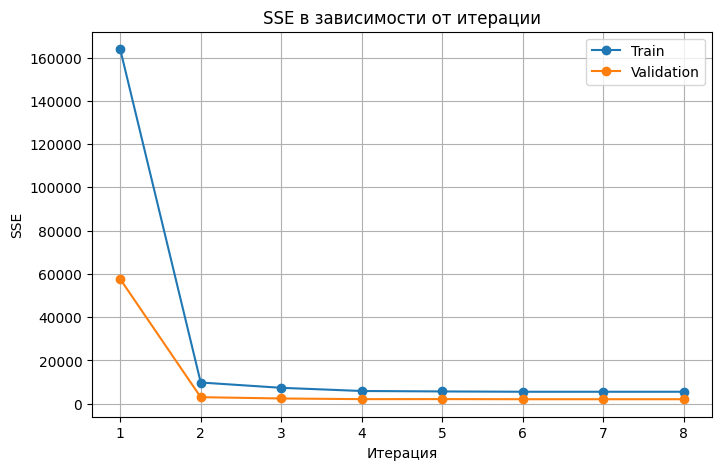

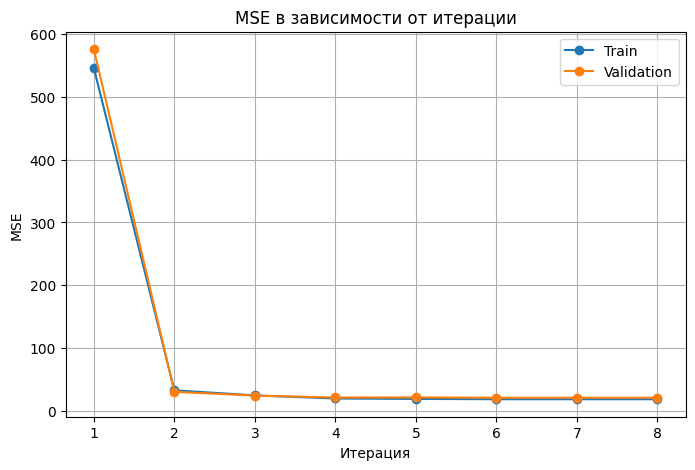

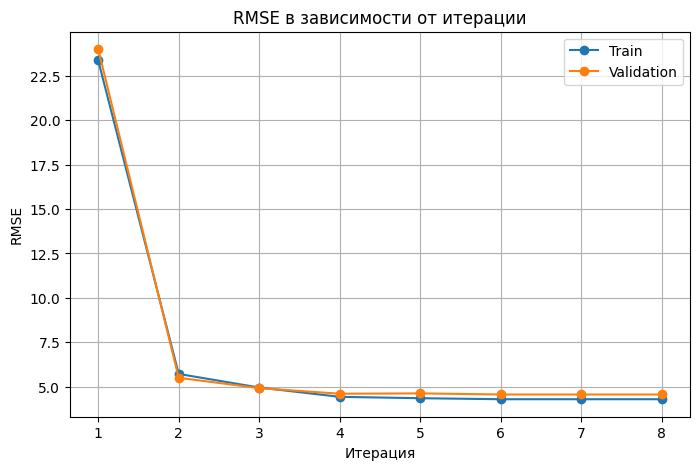

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# pandas-таблицы в numpy
X_train_np = X_train.to_numpy(dtype=float)
y_train_np = y_train.to_numpy(dtype=float)

X_val_np = X_val.to_numpy(dtype=float)
y_val_np = y_val.to_numpy(dtype=float)

# Добавляем столбец единиц для свободного коэффициента w0 
# (если мы этого не сделаем то наша прямая y*=w1xw+...+wnxn юудет обязана проходить через 0, а этого быть не должно)
X_train_aug = np.column_stack([
    np.ones(len(X_train_np)),
    X_train_np
])

X_val_aug = np.column_stack([
    np.ones(len(X_val_np)),
    X_val_np
])

# Строим систему Aw = b
A = X_train_aug.T @ X_train_aug
b = X_train_aug.T @ y_train_np


# Начальные веса
w = np.zeros(X_train_aug.shape[1])

# Начальная невязка
r = b - A @ w

# Начальное направление
p = r.copy()

# Условия остановки
epsilon = 1e-8
max_iterations = 300

# Списки для ошибок
train_sse = []
train_mse = []
train_rmse = []

val_sse = []
val_mse = []
val_rmse = []


# Функция подсчёта ошибок
def calculate_errors(X, y, w):
    y_pred = X @ w

    errors = y_pred - y

    sse = np.sum(errors ** 2)
    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)

    return sse, mse, rmse



# Алгоритм сопряжённых градиентов
for iteration in range(max_iterations):
    # Длина шага 
    alpha = (r.T @ r) / (p.T @ X_train_aug.T @ X_train_aug @ p)

    # Новые веса
    w = w + alpha * p

    # Новая невязка
    r_new = r - alpha * A @ p

    # Считаем ошибки для train
    sse, mse, rmse = calculate_errors(
        X_train_aug,
        y_train_np,
        w
    )

    train_sse.append(sse)
    train_mse.append(mse)
    train_rmse.append(rmse)

    # Считаем ошибки для val
    sse, mse, rmse = calculate_errors(
        X_val_aug,
        y_val_np,
        w
    )

    val_sse.append(sse)
    val_mse.append(mse)
    val_rmse.append(rmse)

    # Проверяем условие остановки
    if np.linalg.norm(r_new) < epsilon:
        print("Обучение завершено")
        print("Количество итераций:", iteration + 1)
        break

    # beta
    beta = (r_new @ r_new) / (r @ r)

    # Новое направление
    p = r_new + beta * p

    # Запоминаем новую невязку
    r = r_new

iterations = range(1, len(train_sse) + 1)

# SSE
plt.figure(figsize=(8, 5))
plt.plot(iterations, train_sse, marker="o", label="Train")
plt.plot(iterations, val_sse, marker="o", label="Validation")
plt.xlabel("Итерация")
plt.ylabel("SSE")
plt.title("SSE в зависимости от итерации")
plt.legend()
plt.grid()
plt.show()


# MSE
plt.figure(figsize=(8, 5))
plt.plot(iterations, train_mse, marker="o", label="Train")
plt.plot(iterations, val_mse, marker="o", label="Validation")
plt.xlabel("Итерация")
plt.ylabel("MSE")
plt.title("MSE в зависимости от итерации")
plt.legend()
plt.grid()
plt.show()


# RMSE
plt.figure(figsize=(8, 5))
plt.plot(iterations, train_rmse, marker="o", label="Train")
plt.plot(iterations, val_rmse, marker="o", label="Validation")
plt.xlabel("Итерация")
plt.ylabel("RMSE")
plt.title("RMSE в зависимости от итерации")
plt.legend()
plt.grid()
plt.show()

#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

Графики говорят, что наша модель хорошо обучилась, потому что с каждой итерацией на тренировочных и на валидационных данных ошибка падает и уменьшается до приемлемой для нас разницы между предугаданным временем доставки и реальным. 

#### Вопрос 3. 

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

1. На графиках недообученной модели траектория линий будет падать, но ошибка у обоих линий не будет приемлемой для текущей задачи.
2. На графиках обученной модели траектория линий будет падать и ошибка у обоих линий будет приемлемой для текущей задачи.
3. На графиках переобученной модели траектория линии train будет падать и ошибка будет приемлемой, но траектория линии val будет сначала падать, а потом возрастет, показывая тем самым, что модель слишком привыкла к данным на тренировочной выборке и на валидационных данных работает плохо

#### Шаг 6. Применение модели на тестовой выборке

In [9]:
# Переводим test в numpy
X_test_np = X_test.to_numpy(dtype=float)
y_test_np = y_test.to_numpy(dtype=float)

# Добавляем столбец единиц для w0
X_test_aug = np.column_stack([
    np.ones(len(X_test_np)),
    X_test_np
])

y_predict_test = X_test_aug @ w

#### Шаг 7. RMSE на тестовой выборке

In [10]:

errors = y_predict_test - y_test_np

mse = np.mean(errors ** 2)
rmse = np.sqrt(mse)

rmse

np.float64(4.831131903177559)

#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

Получившийся RMSE показывает насколько ошибается модель в своих прогнозах. Ошибка 4,8 показывает что модель в среднем ошибается на 4,8 минут, что для времени доставки приемлемо.  